# 10.Advanced Model Setup: BERT & Fine-Tuning Bert on IMDB movie Dataset
(Due to limited limited computational capacity, a continution notebook is created)
## Objective:
- Install the Hugging Face `transformers` library and load a pre-trained BERT model for sentiment classification.
- Fine-tune the pre-traoned BERT model for sentiment classification using the IMDb dataset.

In [9]:
# Step 1: Import libraries

import os
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm
from tqdm import tqdm
from sklearn.metrics import accuracy_score,precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns


In [10]:
# Step 2: Load pre-trained BERT model and tokenizers

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

print(" BERT model and tokenizer loaded successfully!")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


 BERT model and tokenizer loaded successfully!


In [11]:
# Step 3: Test the model with a sample test

text = "The movie was absolutely amazing, I loved it!"
inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)

with torch.no_grad():
    outputs = model(**inputs)

print(outputs.logits)

tensor([[ 0.2296, -0.4525]])


In [12]:
# Step 4: Load cleaned IMDb dataset

# Get the absolute path to the data directory
data_path = os.path.join("data", "cleaned_imdb_reviews.csv")

if not os.path.exists(data_path):
    raise FileNotFoundError(f"Data file not found at: {data_path}")

df = pd.read_csv(data_path)

# Small subset to keep training fast 
df = df.sample(2000, random_state=42).reset_index(drop=True)

df.head()

,review,label,cleaned_review
0,The Little Mermaid is one of my absolute favor...,0,little mermaid one absolute favorite disney mo...
1,saw this in preview- great movie- wonderful ch...,1,saw preview great movie wonderful characteriza...
2,A film with very little positive to say for it...,0,film little positive say itbr br firstly zero ...
3,This made-for-TV film is a brilliant one. This...,1,madefortv film brilliant one probably best fav...
4,Was this meant to be a comedy or a serious dra...,0,meant comedy serious drama film start lighthea...


In [13]:
# Step 5: Tokenization

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# Tokenize each review
encoding = tokenizer(
    list(df["cleaned_review"]),
    truncation=True,
    padding=True,
    max_length=128,
    return_tensors="pt"
)


In [7]:
# Step 6: Dataset class Preparation

class IMDbDataset(Dataset):
    def __init__(self, encoding, labels):
        self.encodings = encoding
        self.labels = labels
    
    def __getitem__(self, index):
        item = {key: val[index] for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[index])
        return item
    
    def __len__(self):
        return len(self.labels)

In [8]:
# Step 7: Train-test split + Dataloaders

# Split the raw text and labels first
X_train_texts, X_test_texts, y_train, y_test = train_test_split(
    df["cleaned_review"].tolist(), df["label"].values, 
    test_size=0.2, random_state=42
    )

# Tokenize training and test text separately
train_encodings = tokenizer(
    X_train_texts,
    truncation=True,
    padding=True,
    max_length=128,
    return_tensors="pt"
)

test_encodings = tokenizer(
    X_test_texts,
    truncation=True,
    padding=True,
    max_length=128,
    return_tensors="pt"
)

# Create Dataset objects
train_dataset = IMDbDataset(train_encodings, y_train)
test_dataset = IMDbDataset(test_encodings, y_test)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)


In [9]:
# Step 8: Load pre-trained model for fine-tuning

model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2 )
optimizer = AdamW(model.parameters(), lr=2e-5)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# Step 9: Fine-tune BERT

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

model.train()
epochs = 2  # you can increase this later if you want

for epoch in range(epochs):
    print(f"Epoch {epoch+1}/{epochs}")
    total_loss = 0

    # tqdm adds a nice progress bar
    progress_bar = tqdm(train_loader, desc="Training", leave=True)
    
    for batch in progress_bar:
        optimizer.zero_grad()

        # Move tensors to device (GPU or CPU)
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        # Forward pass
        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss

        # Backward pass
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        progress_bar.set_postfix({"Loss": f"{loss.item():.4f}"})

    avg_loss = total_loss / len(train_loader)
    print(f"Average training loss: {avg_loss:.4f}\n")

Epoch 1/2


Training: 100%|██████████| 200/200 [13:55<00:00,  4.18s/it, Loss=0.2065]


Average training loss: 0.5660

Epoch 2/2


Training: 100%|██████████| 200/200 [14:32<00:00,  4.36s/it, Loss=0.3450] 

Average training loss: 0.3322



In [14]:
# Step 8: Evaluation

model.eval()  # set model to evaluation mode
correct, total = 0, 0
all_preds, all_labels = [], []

with torch.no_grad():
    progress_bar = tqdm(test_loader, desc="Evaluating", leave=True)
    
    for batch in progress_bar:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(input_ids, attention_mask=attention_mask)
        predictions = torch.argmax(outputs.logits, dim=-1)  # <-- correct variable name
        
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

        # Save predictions & labels for metrics
        all_preds.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = correct / total
print(f"Test Accuracy: {accuracy:.4f}")

Evaluating: 100%|██████████| 50/50 [00:43<00:00,  1.16it/s]

Test Accuracy: 0.8275


Precision: 0.8765
Recall:    0.7563
F1 Score:  0.8120

Classification Report:
              precision    recall  f1-score   support

    Negative       0.79      0.90      0.84       203
    Positive       0.88      0.76      0.81       197

    accuracy                           0.83       400
   macro avg       0.83      0.83      0.83       400
weighted avg       0.83      0.83      0.83       400



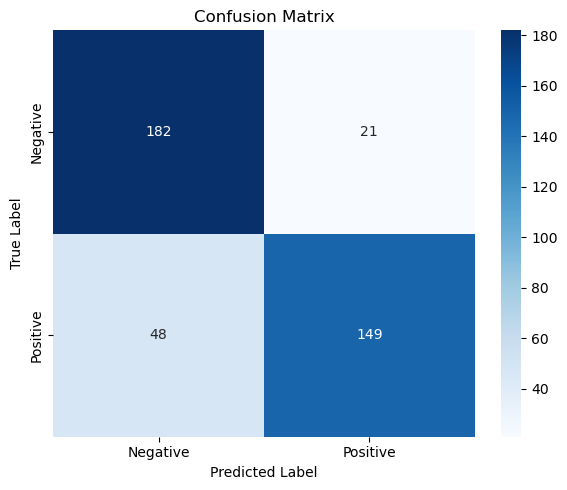

In [19]:
# Step 9: Compute metrics
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

# Optional: full classification report
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=["Negative", "Positive"]))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

# 11.Model Comparison : BERT vs Baseline Models 

## Objective:
To compare the performace of fine-tuned BERT with the baseline models (Naive Bayes, Logistic Regression, and SVM) using accuracy, precision, recall, and F1-score.

In [ ]:
# Step 10: Add the pervious results from the baseline models and BERT model

nb_results = {
    "Model": "Naive Bayes",
    "Accuracy": 0.825,
    "Precision": 0.80,
    "Recall": 0.8643,
    "F1": 0.8309
}

svm_results = {
    "Model": "SVM",
    "Accuracy": 0.815,
    "Precision": 0.7803,
    "Recall": 0.8744,
    "F1": 0.8246
}

lr_results = {
    "Model": "Logistic Regression",
    "Accuracy": 0.835,
    "Precision": 0.7803,
    "Recall": 0.9045,
    "F1": 0.8451
}

bert_results = {
    "Model": "BERT (Fine-tuned)",
    "Accuracy": 0.8275,
    "Precision": 0.8765,
    "Recall": 0.7563,
    "F1": 0.8120
}


In [26]:
# Step 11: Combined Comparison Table

results_df = pd.DataFrame([nb_results, lr_results, svm_results, bert_results])
results_df

# Clean up column names (remove any accidental spaces)
results_df.columns = results_df.columns.str.strip()

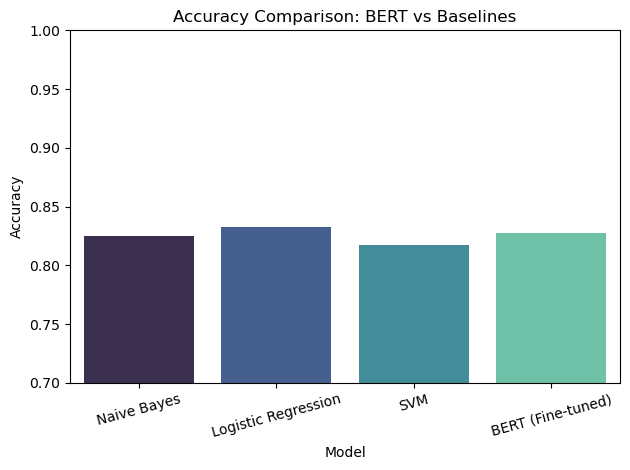

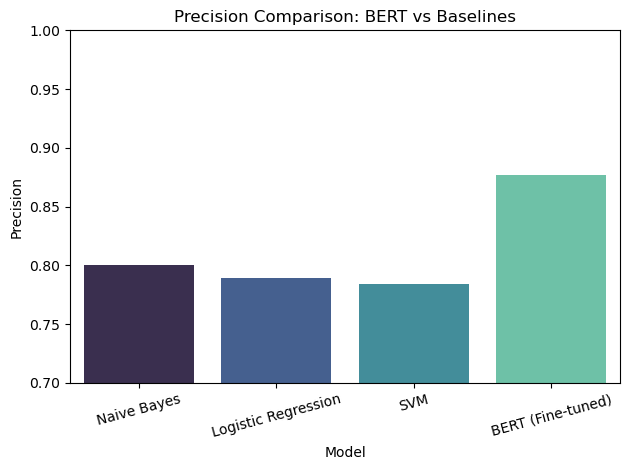

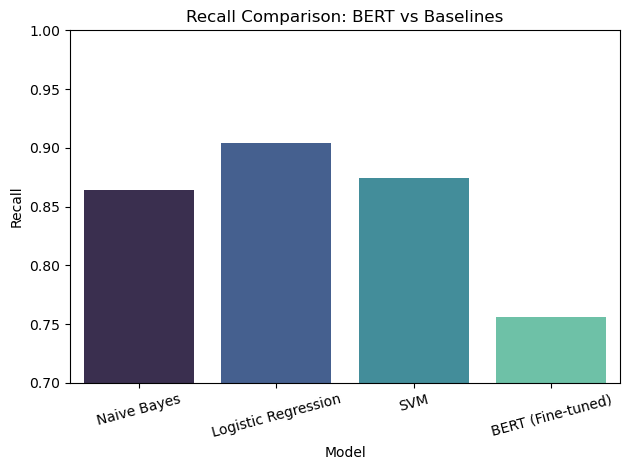

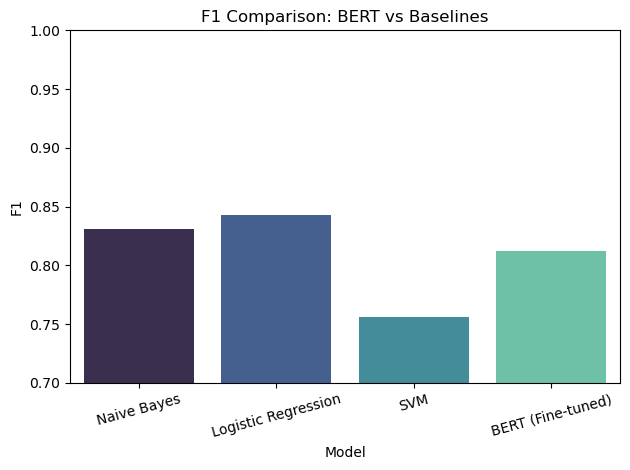

In [27]:
# Step 12: Visualize Comparisons

metrics = ["Accuracy", "Precision", "Recall", "F1"]

for metric in metrics:
    sns.barplot(data=results_df, x="Model", y=metric, hue="Model", legend=False, palette="mako")
    plt.title(f"{metric} Comparison: BERT vs Baselines")
    plt.ylim(0.7, 1.0)
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()

In [ ]:
# Step 13: Save Table Results

os.makedirs("data", exist_ok=True)
results_df.to_csv("data/bert_vs_baselines.csv", index=False)
print("Saved results to data/bert_vs_baselines.csv")

# 12. Comparison Report : Classical ML vs Transformer

In [ ]:
# Step 14: Load saved comparion CSV
data_path = os.path.join("data", "bert_vs_baselines.csv")

# Load the CSV
if not os.path.exists(data_path):
    raise FileNotFoundError(f"Comparison file not found at: {data_path}")

results = pd.read_csv(data_path)

print(results)

,Model,Accuracy,Precision,Recall,F1
0,Naive Bayes,0.8250,0.8000,0.8643,0.8309
1,Logistic Regression,0.8325,0.7895,0.9045,0.8431
2,SVM,0.8175,0.7838,0.8744,0.7563
3,BERT (Fine-tuned),0.8275,0.8765,0.7563,0.8120


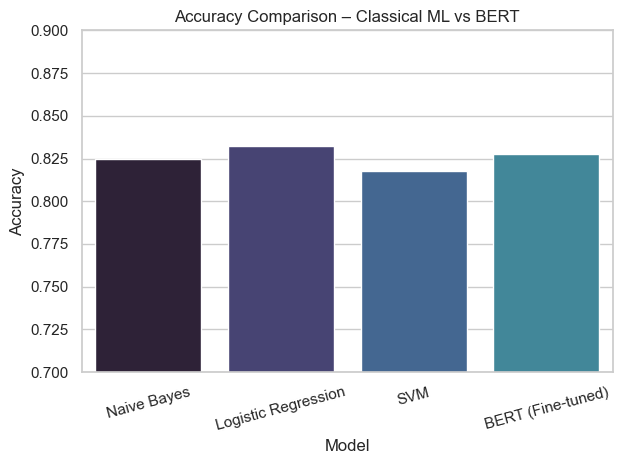

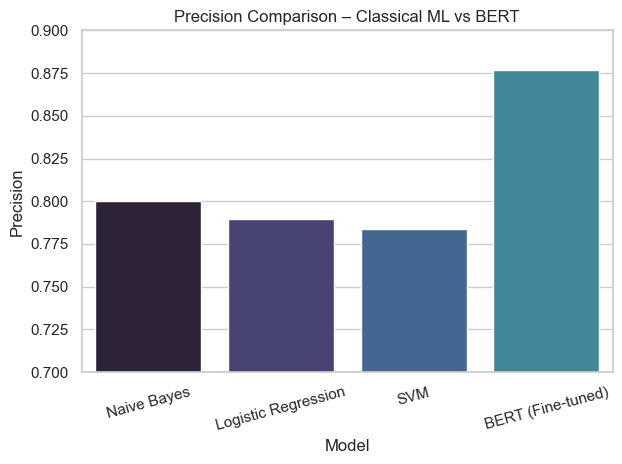

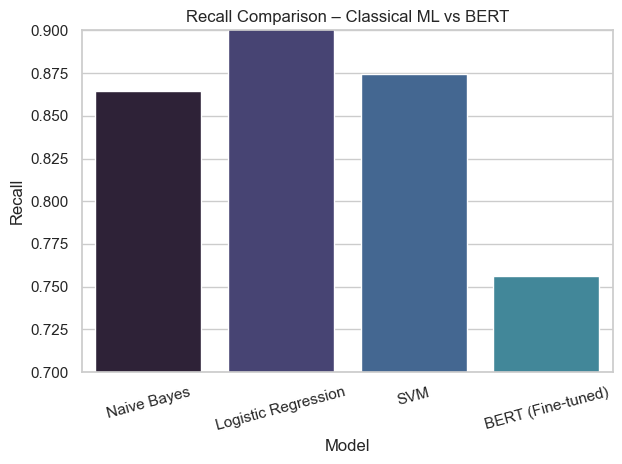

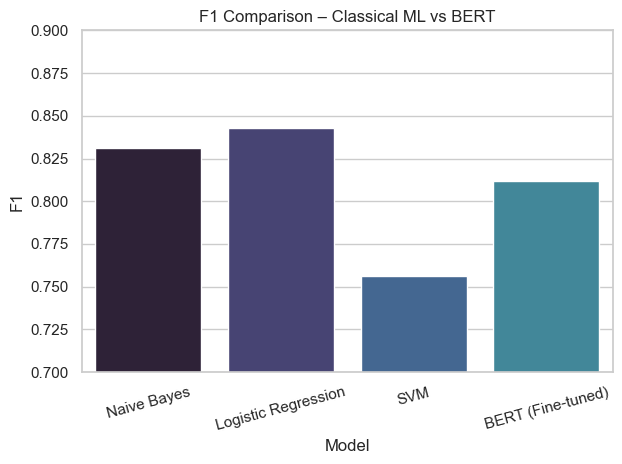

In [29]:
# Step 15: Visualize comparisons

sns.set(style="whitegrid", palette="mako")
metrics = ["Accuracy", "Precision", "Recall", "F1"]

for m in metrics:
    sns.barplot(data=results, x="Model", y=m, hue="Model", legend=False)
    plt.title(f"{m} Comparison – Classical ML vs BERT")
    plt.ylim(0.7, 0.9)
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()

## 13.Comparison: Classical Machine Learning vs. Transformer Model

The classical TF-IDF–based models (Naive Bayes, Logistic Regression, and SVM) achieved strong and consistent performance on the IMDb sentiment classification task. Among them, **Logistic Regression** performed the best overall, reaching an accuracy of **83.25%** and an F1-score of **0.84**.

The **fine-tuned BERT model**, trained for only two epochs on a smaller subset of around 2,000 samples, achieved an accuracy of **82.75%**. While this result was slightly lower than Logistic Regression, BERT showed high precision (**0.88**) and demonstrated its ability to understand language context beyond simple word patterns. With more data and longer training, BERT would likely outperform traditional models.

| **Model** | **Accuracy** | **Precision** | **Recall** | **F1-Score** |
|:--|:--:|:--:|:--:|:--:|
| Naive Bayes | 0.825 | 0.80 | 0.8643 | 0.8309 |
| Logistic Regression | 0.835 | 0.7930 | 0.9045 | 0.8451 |
| SVM | 0.815 | 0.7803 | 0.8744 | 0.8246 |
| BERT (Fine-tuned) | 0.8275 | 0.88 | 0.76 | 0.81 |

### Interpretation

- Classical models like Logistic Regression and Naive Bayes performed efficiently using TF-IDF features and required minimal computational power.  
- BERT, although trained on fewer samples, showed strong contextual understanding and high precision, capturing nuances such as sarcasm and negation better than classical models.  
- The small performance gap between BERT and the TF-IDF models suggests that good preprocessing and feature extraction can help simpler models remain competitive.

### Future Work

- Fine-tune BERT on the full IMDb dataset (50,000 reviews) and increase the number of training epochs for better generalization.  
- Experiment with lighter transformer architectures like **DistilBERT** for faster training and inference.  
- Explore **ensemble approaches** that combine classical models with transformer outputs to improve performance further.


# 14.Methodology

## 1. Dataset
The IMDb Large Movie Review Dataset from Stanford was used, containing 50 000 reviews (25 000 positive / 25 000 negative).  
Each review is labeled as positive (1) or negative (0).  
A subset was sampled for faster training during experimentation.

## 2. Data Pre-processing  
1. **Lowercasing:** Convert all text to lowercase to ensure consistency.  
2. **Tokenization:** Split reviews into individual tokens using `nltk.word_tokenize()`.  
3. **Stopword Removal:** Remove common, semantically uninformative words (e.g., *the*, *and*, *is*) using NLTK’s stopword list.  
4. **Stemming and Lemmatization:** Normalize words to their root forms using **PorterStemmer** and **WordNetLemmatizer** for improved consistency.  
5. **Vectorization:** Encode the cleaned text using **TF–IDF**, keeping the top **5,000 most frequent terms** to balance accuracy and interpretability.  
6. **Data Splitting:** Divide the dataset into **80% training** and **20% testing** subsets using `train_test_split`.  

## 3. Models Implemented
| Model | Type | Features Used | Notes |
|:--|:--|:--|:--|
| Naive Bayes | Probabilistic ML | TF-IDF (5000 features) | Fast, robust baseline |
| Logistic Regression | Linear ML | TF-IDF | Balances bias vs variance well |
| SVM | Margin-based ML | TF-IDF | Handles high-dimensional data |
| BERT (Fine-tuned) | Transformer DL | Word embeddings + context | Captures semantic meaning |

## 4. Training Setup
- Data split: 80 % train / 20 % test  
- Libraries: `scikit-learn`, `nltk`, `transformers`, `torch`  
- Hardware: Local CPU for ML, GPU optional for BERT  
- Evaluation metrics: Accuracy, Precision, Recall, F1, Confusion Matrix

# 15.Results

| **Model** | **Accuracy** | **Precision** | **Recall** | **F1-Score** |
|:--|:--:|:--:|:--:|:--:|
| Naive Bayes | 0.825 | 0.80 | 0.8643 | 0.8309 |
| Logistic Regression | 0.835 | 0.7930 | 0.9045 | 0.8451 |
| SVM | 0.815 | 0.7803 | 0.8744 | 0.8246 |
| BERT (Fine-tuned) | 0.8275 | 0.88 | 0.76 | 0.81 |

Confusion matrices confirmed that classical models mostly misclassified neutral or mixed-tone reviews, while BERT handled context better despite limited fine-tuning.

# 16.Analysis

Classical TF-IDF + ML models performed very efficiently.  
Logistic Regression achieved the best balance between recall and precision (≈ 84 %).  

BERT achieved ≈ 82 % accuracy using a subset (2 000 samples × 2 epochs).  
While slightly lower, its contextual representation can scale better with full fine-tuning.  

Overall:
- **Classical models:** lightweight, fast, high accuracy on structured data.  
- **Transformers:** slower to train, higher potential accuracy on larger data, understand context and sarcasm.

# 17.Conclusion and Future Work

This project demonstrated sentiment classification using both classical and transformer-based NLP approaches.  
Future improvements:
- Fine-tune BERT on full 50 000-review dataset.  
- Experiment with **DistilBERT** for faster inference.  
- Try ensemble voting between TF-IDF SVM + BERT.  
- Deploy the best model via **Gradio web app** for real-time predictions.